In [1]:
import re
import ipaddress
import pathlib
import os

import cbor2
import polars
import IPython.display
from tqdm.notebook import tqdm

DNSCBOR_EVAL_DIR = pathlib.Path.cwd()
os.environ["DNSCBOR_EVAL_DIR"] = str(DNSCBOR_EVAL_DIR)

# base17-compression of IPv6 addresses

This explores an option for AAAA record compression that is not part of `draft-lenders-dns-cbor`. See https://github.com/cbor-wg/cbor-dns/issues/9. For this, you require the `dns_addrs_{iot,tranco}.csv.gz` in `04_cbor4dns_eval/output_datasets/` as generated in [“Prepararations for Common IP Prefixes and Name Suffixes Analysis](./03_comp_pot_prep.ipynb#Extract-Addresses).

In [2]:
base_lf = polars.scan_csv(
    [
        DNSCBOR_EVAL_DIR / "output_datasets" / "dns_addrs_iot.csv.gz",
        DNSCBOR_EVAL_DIR / "output_datasets" / "dns_addrs_tranco.csv.gz",
    ]
)

lf = None

for col in ["x", "y"]:
    tmp = base_lf.filter(
        (polars.col(f"Field {col}") != "_ws.col.Source")
        & (polars.col(f"Field {col}") != "_ws.col.Destination")
        & (polars.col(f"Address {col}").str.len_chars() == 32)
    ).select("dataset", f"Field {col}", f"Address {col}").rename(
        {
            f"Address {col}": "Address",
            f"Field {col}": "Field",
        }
    )
    
    if lf is None:
        lf = tmp
    else:
        lf = polars.concat([lf, tmp]).unique()

lf.collect()

dataset,Field,Address
str,str,str
"""tranco""","""dns.aaaa""","""26009000268098000010b80dbf4093…"
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","""260647003033000000000000681544…"
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","""26064700001000000000000068163f…"
"""tranco""","""dns.aaaa""","""2606470000000000000000006810d7…"
"""tranco""","""dns.aaaa""","""26001f1603a4030cf58c895aedf42f…"
…,…,…
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","""26064700303300000000000068151a…"
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","""260647000010000000000000681628…"
"""tranco""","""dns.aaaa""","""260647000020000000000000681a0a…"


In [3]:
def to_base17(addr, improved=False):
    addr = ipaddress.IPv6Address(addr)
    addr = addr._string_from_ip_int(addr._ip)
    if improved:
        def improve(addr):
            addr = re.sub(":([0-9a-f]{4})", r"\1", addr)
            if addr.startswith(":"):
                return addr[1:]
            else:
                return addr
    else:
        improve = lambda addr: addr
    base17_str = improve(re.sub("([0-9a-f]{4}):", r"\1", addr)).replace(":", "g")
    return cbor2.dumps(int(base17_str, base=17))


def max_zero_run_with_position(bytes_data):
    max_length = 0
    max_start = -1  # Default if no zeros are found
    current_length = 0
    current_start = None  # Tracks the start of the current run

    for index, byte in enumerate(bytes_data):
        if byte == 0:
            # Start a new run if not in one
            if current_length == 0:
                current_start = index
            current_length += 1
            # Update max if current run is the longest so far
            if current_length > max_length:
                max_length = current_length
                max_start = current_start
        else:
            # Reset counters if non-zero byte encountered
            current_length = 0
            current_start = None

    if max_length < 2:
        return (0, -1)  # No zero run found
    else:
        return (max_length, max_start)


def carstens_method(addr, mac_optimization=False):
    addr = addr
    if mac_optimization:
        if addr[11] == 0xff and addr[12] == 0xfe:
            addr = addr[:8] + bytes([addr[8] ^ 0x02]) + addr[9:11] + addr[13:]
    max_length, max_start = max_zero_run_with_position(addr)
    if max_start >= 0:
        addr = bytes([max_length]) + addr[:max_start] + addr[max_start + max_length:]
    return cbor2.dumps(addr)

lf = lf.with_columns(
    polars.col("Address").str.decode("hex")
).with_columns(
    polars.col("Address").map_elements(
        cbor2.dumps,
        return_dtype=polars.Binary,
    ).alias("CBOR"),
    polars.col("Address").map_elements(
        to_base17,
        return_dtype=polars.Binary,
    ).alias("base17 Compressed"),
    polars.col("Address").map_elements(
        lambda a: to_base17(a, True),
        return_dtype=polars.Binary,
    ).alias("base17 Compressed improved"),
    polars.col("Address").map_elements(
        carstens_method,
        return_dtype=polars.Binary,
    ).alias("Carsten Compressed"),
    polars.col("Address").map_elements(
        lambda a: carstens_method(a, True),
        return_dtype=polars.Binary,
    ).alias("Carsten Compressed improved"),
)

lf.collect()

dataset,Field,Address,CBOR,base17 Compressed,base17 Compressed improved,Carsten Compressed,Carsten Compressed improved
str,str,binary,binary,binary,binary,binary,binary
"""tranco""","""dns.aaaa""","b""&\x00\x90\x00#N\xfa\x00\x00\x19\x1e\xd7\x85\x80\x93\xa1""","b""P&\x00\x90\x00#N\xfa\x00\x00\x19\x1e\xd7\x85\x80\x93\xa1""","b""\xc2P\x0e\x81\x1e\xf0\xe2Z\xd5D#\r=\xe0O\x9b\xba""","b""\xc2O\xdak;X\x9b\xeemk|,\xbd\xbeW\xa1\xfa""","b""O\x02&\x00\x90\x00#N\xfa\x19\x1e\xd7\x85\x80\x93\xa1""","b""O\x02&\x00\x90\x00#N\xfa\x19\x1e\xd7\x85\x80\x93\xa1"""
"""tranco""","""dns.aaaa""","b""&\x00\x90\x00""`D\x00\x00\x12\x04\xab\x8d\x80\x93\xa1""","b""P&\x00\x90\x00""`D\x00\x00\x12\x04\xab\x8d\x80\x93\xa1""","b""\xc2P\x0e\x81\x1e\xf0\xe2%\x81.\xb3\xe0Ws\x0d\xd2Q\xb3""","b""\xc2O\xdak;X\x98\xcb]\x19\xa3\xc8\xe7\xe9\x87J\xb3""","b""O\x02&\x00\x90\x00""`D\x12\x04\xab\x8d\x80\x93\xa1""","b""O\x02&\x00\x90\x00""`D\x12\x04\xab\x8d\x80\x93\xa1"""
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","b""&\x06G\x0002\x00\x00\x00\x00\x00\x00\xacC\xcc@""","b""P&\x06G\x0002\x00\x00\x00\x00\x00\x00\xacC\xcc@""","b""\xc2K\x07\xea\x1ej?\x05\xe8\xf4>\xf9\x1a""","b""\xc2Jw.\xf70\xe2:P\xa3\xf2\xfa""","b""K\x06&\x06G\x0002\xacC\xcc@""","b""K\x06&\x06G\x0002\xacC\xcc@"""
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","b""&\x06G\x0005\x00\x00\x00\x00\x00\x00\xacC\xb8\x0e""","b""P&\x06G\x0005\x00\x00\x00\x00\x00\x00\xacC\xb8\x0e""","b""\xc2K\x07\xea\x1ej?\x06;\xc9i\x0e\xe2""","b""\xc2Jw.\xf70\xe2?0\x00\xb0\x92""","b""K\x06&\x06G\x0005\xacC\xb8\x0e""","b""K\x06&\x06G\x0005\xacC\xb8\x0e"""
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","b""&\x06G\x0007\x00\x00\x00\x00\x00\x00\xacC\xba\x92""","b""P&\x06G\x0007\x00\x00\x00\x00\x00\x00\xacC\xba\x92""","b""\xc2K\x07\xea\x1ej?\x06s\x02/\xda\xd3""","b""\xc2Jw.\xf70\xe2Bo\x93\xecc""","b""K\x06&\x06G\x0007\xacC\xba\x92""","b""K\x06&\x06G\x0007\xacC\xba\x92"""
…,…,…,…,…,…,…,…
"""tranco""","""dns.svcb.svcparam.ipv6hint.ip""","b""&\x06G\x00\x00\x00\x00\x00\x00\x00\x00\x00h\x11\x0b\x10""","b""P&\x06G\x00\x00\x00\x00\x00\x00\x00\x00\x00h\x11\x0b\x10""","b""\x1b]\x84\xe2\x84\xb5\x9d5\xa5""","b""\x1b\x05\x80I\x8fG\xb9\x8a\x05""","b""H\x09&\x06Gh\x11\x0b\x10""","b""H\x09&\x06Gh\x11\x0b\x10"""
"""tranco""","""dns.aaaa""","b""&\x06G\x00\x00\x00\x00\x00\x00\x00\x00\x00h\x13\xb7_""","b""P&\x06G\x00\x00\x00\x00\x00\x00\x00\x00\x00h\x13\xb7_""","b""\xc2I\x065\xd3\x0a\xd0\x0fs#\xa1""","b""\x1b]\x84\xe2\x83\xc3T\xbe\x01""","b""H\x09&\x06Gh\x13\xb7_""","b""H\x09&\x06Gh\x13\xb7_"""
"""tranco""","""dns.aaaa""","b""&\x06G\x0005\x00\x00\x00\x00\x00\x00h\x15\x01=""","b""P&\x06G\x0005\x00\x00\x00\x00\x00\x00h\x15\x01=""","b""\xc2Jw.\xf70\xe2?\xbar\x16\xd9""","b""\xc2J\x07\x02\xc3?\x1c^\x0b\xc6M\x89""","b""K\x06&\x06G\x0005h\x15\x01=""","b""K\x06&\x06G\x0005h\x15\x01="""


In [4]:
lf.with_columns(
    (
        polars.col("CBOR").bin.size().cast(polars.Int8) - polars.col("base17 Compressed").bin.size()
    ).alias("base17 Byte Savings"),
    (
        polars.col("CBOR").bin.size().cast(polars.Int8) - polars.col("base17 Compressed improved").bin.size()
    ).alias("base17 Byte Savings improved"),
    (
        polars.col("CBOR").bin.size().cast(polars.Int8) - polars.col("Carsten Compressed").bin.size()
    ).alias("Carsten Byte Savings"),
    (
        polars.col("CBOR").bin.size().cast(polars.Int8) - polars.col("Carsten Compressed improved").bin.size()
    ).alias("Carsten Byte Savings improved"),
).with_columns(
    (
        polars.col("base17 Byte Savings") / polars.col("CBOR").bin.size()
    ).alias("base17 Gain"),
    (
        polars.col("base17 Byte Savings improved") / polars.col("CBOR").bin.size()
    ).alias("base17 Gain improved"),
    (
        polars.col("Carsten Byte Savings") / polars.col("CBOR").bin.size()
    ).alias("Carsten Gain"),
    (
        polars.col("Carsten Byte Savings improved") / polars.col("CBOR").bin.size()
    ).alias("Carsten Gain improved"),
).sink_parquet(
    DNSCBOR_EVAL_DIR / "output_datasets" / "base17-stats.parquet",
    compression="zstd",
    compression_level=22,
)

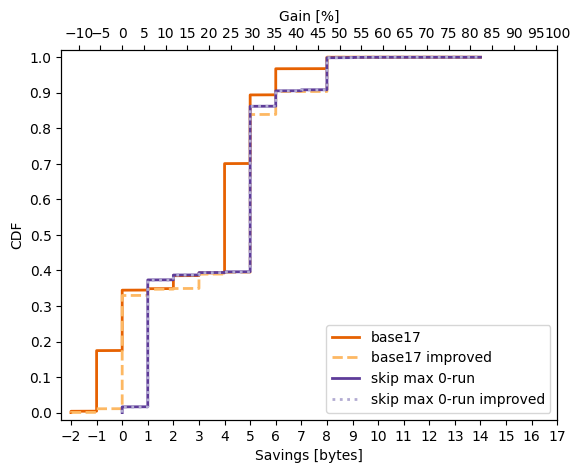

In [5]:
from cycler import cycler

import matplotlib.pyplot
import matplotlib.ticker
import numpy

DATASETS = {
    "all": ["yourthings", "iotfinder", "moniotr", "tranco"],
    "iot": ["yourthings", "iotfinder", "moniotr"],
    "tranco": ["tranco"],
}
LABEL = {
    "all": "Both",
    "iot": "IoT",
    "tranco": "Public",
}
STYLE = {
    "all": "-",
    "iot": "--",
    "tranco": ":",
}

default_cycler = (cycler(color=['#e66101', '#fdb863', '#5e3c99', '#b2abd2']) +
                  cycler(linestyle=['-', '--', '-', ':']))

matplotlib.pyplot.rc('lines', linewidth=2)
matplotlib.pyplot.rc('axes', prop_cycle=default_cycler)

ax = matplotlib.pyplot.gca()
secax = ax.twiny()

lf = polars.scan_parquet(DNSCBOR_EVAL_DIR / "output_datasets" / "base17-stats.parquet")

for filt in ["all"]: #, "tranco", "iot"]:
    for method in ["base17", "Carsten"]:
        for impr in ["", " improved"]:
            #selection = df[df["dataset"].isin(DATASETS[filt])]
            #selection.drop_duplicates(subset=["Address"])
            selection = lf.filter(
                polars.col("dataset").is_in(DATASETS[filt])
            ).unique("Address").collect()
            
            x = numpy.sort(selection[f"{method} Byte Savings{impr}"])
            y = numpy.arange(selection[f"{method} Byte Savings{impr}"].shape[0]) / selection[f"{method} Byte Savings{impr}"].shape[0]
            
            ax.plot(x, y, label=(method if method == "base17" else "skip max 0-run") + impr)
            
            x = numpy.sort(selection[f"{method} Gain{impr}"])
            y = numpy.arange(selection[f"{method} Gain{impr}"].shape[0]) / selection[f"{method} Gain{impr}"].shape[0]

            secax.plot(x, y, color="none")
            del selection

ax.set_xlabel("Savings [bytes]")
ax.set_xlim(
    (
        -0.14 * 17,
        17,
    )
)
ax.set_xticks(
    numpy.arange(
        -2,
        18,
        1
    )
)
secax.set_xlabel(r"Gain [%]")
secax.set_xlim(
    (
        -0.14,
        1,
    )
)
secax.set_xticks(
    numpy.arange(
        -0.1,
        1.05,
        0.05
    )
)
secax.xaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(xmax=1, decimals=0, symbol="")
)

ax.set_ylabel("CDF")
ax.set_ylim((-0.02, 1.02))
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.legend(loc="lower right")


matplotlib.pyplot.savefig(
    "/users/lenders/skip-max-0-run.png",
    bbox_inches="tight",
    pad_inches=0.01,
)
matplotlib.pyplot.show()

In [6]:
def test_mac_optimization(addr):
    addr = addr
    if addr[11] == 0xff and addr[12] == 0xfe:
        addr = addr[:8] + bytes([addr[8] ^ 0x02]) + addr[9:11] + addr[13:]
    return addr

df = lf.filter(
    polars.col("Address").bin.encode("hex").str.slice(22, 4) == "fffe"
).with_columns(
    polars.col("Address").map_elements(
        test_mac_optimization,
        return_dtype=polars.Binary
    ).alias("Address, MAC optimized")
).with_columns(
    Difference=polars.col("Address").bin.size() - polars.col("Address, MAC optimized").bin.size()
).select("Address", "Address, MAC optimized", "Difference").collect()
IPython.display.display(df)

Address,"Address, MAC optimized",Difference
binary,binary,u32
"b""\xfe\x80\x00\x00\x00\x00\x00\x00\xba,\xa0\xff\xfe(>k""","b""\xfe\x80\x00\x00\x00\x00\x00\x00\xb8,\xa0(>k""",2
"b""*\x01~\x01\x00\x00\x00\x00\xf0<\x92\xff\xfe\xe2\x1f\x17""","b""*\x01~\x01\x00\x00\x00\x00\xf2<\x92\xe2\x1f\x17""",2
"b""*\x00\x18\xc8\x10\x01\xff\xf0\x02\x1b!\xff\xfep\x8b\xc5""","b""*\x00\x18\xc8\x10\x01\xff\xf0\x00\x1b!p\x8b\xc5""",2
"b""*\x01~\x01\x00\x00\x00\x00\xf0<\x92\xff\xfe\x92y~""","b""*\x01~\x01\x00\x00\x00\x00\xf2<\x92\x92y~""",2
"b""*\x0br\x80\x01\x00\x00\x00\x04\xc3\xb8\xff\xfe\x00\x20\xa5""","b""*\x0br\x80\x01\x00\x00\x00\x06\xc3\xb8\x00\x20\xa5""",2
…,…,…
"b""&\x00<\x02\x00\x00\x00\x00\xf0<\x91\xff\xfe\x16\x0eH""","b""&\x00<\x02\x00\x00\x00\x00\xf2<\x91\x16\x0eH""",2
"b""\x20\x03\x00\xe0w\x06N\x00\xc4\xe8N\xff\xfe\xe2\xf4i""","b""\x20\x03\x00\xe0w\x06N\x00\xc6\xe8N\xe2\xf4i""",2
"b""*\x01~\x01\x00\x00\x00\x00\xf0<\x94\xff\xfe{e9""","b""*\x01~\x01\x00\x00\x00\x00\xf2<\x94{e9""",2
